## Exercise 3, Main Notebook
_Using `SVC`_

<br>
<br>




### Dataset: [Student Alcohol Consumption](https://www.kaggle.com/datasets/uciml/student-alcohol-consumption)

|Parameter|Description|
|---|---|
|Shape|`__`|
|Target Variable|`__`|
|Method:|`__`
|Extra Tools:|`__`|

<br>

<i>
<strong style='color:red ; background-color:black;'> 

#### Disclosure: 

I used AI to convert the table from the kaggle dataset webpage into a markdown table.

#### Prompt:

 /paste Kaggle column descriptions/. 
 
 Could you put this into a markdown table for me? 
 
</strong>
</i>

| Column Number | Column Name | Column Description                                                             |
| ------------- | ----------- | ------------------------------------------------------------------------------ |
| 1             | school      | Student’s school (binary: GP = Gabriel Pereira, MS = Mousinho da Silveira)     |
| 2             | sex         | Student’s sex (binary: F = female, M = male)                                   |
| 3             | age         | Student’s age (numeric: 15–22)                                                 |
| 4             | address     | Home address type (binary: U = urban, R = rural)                               |
| 5             | famsize     | Family size (binary: LE3 ≤ 3, GT3 > 3)                                         |
| 6             | Pstatus     | Parent cohabitation status (binary: T = together, A = apart)                   |
| 7             | Medu        | Mother’s education (0 none, 1 primary, 2 5th–9th grade, 3 secondary, 4 higher) |
| 8             | Fedu        | Father’s education (same scale as Medu)                                        |
| 9             | Mjob        | Mother’s job (teacher, health, services, at_home, other)                       |
| 10            | Fjob        | Father’s job (teacher, health, services, at_home, other)                       |
| 11            | reason      | Reason for choosing school (home, reputation, course, other)                   |
| 12            | guardian    | Student’s guardian (mother, father, other)                                     |
| 13            | traveltime  | Travel time to school (1 <15m, 2 15–30m, 3 30–60m, 4 >60m)                     |
| 14            | studytime   | Weekly study time (1 <2h, 2 2–5h, 3 5–10h, 4 >10h)                             |
| 15            | failures    | Past class failures (n if 1≤n<3, else 4)                                       |
| 16            | schoolsup   | Extra educational support (yes/no)                                             |
| 17            | famsup      | Family educational support (yes/no)                                            |
| 18            | paid        | Extra paid classes (yes/no)                                                    |
| 19            | activities  | Extra-curricular activities (yes/no)                                           |
| 20            | nursery     | Attended nursery school (yes/no)                                               |
| 21            | higher      | Wants higher education (yes/no)                                                |
| 22            | internet    | Internet access at home (yes/no)                                               |
| 23            | romantic    | Romantic relationship (yes/no)                                                 |
| 24            | famrel      | Family relationship quality (1 very bad → 5 excellent)                         |
| 25            | freetime    | Free time after school (1 very low → 5 very high)                              |
| 26            | goout       | Going out with friends (1 very low → 5 very high)                              |
| 27            | Dalc        | Workday alcohol consumption (1 very low → 5 very high)                         |
| 28            | Walc        | Weekend alcohol consumption (1 very low → 5 very high)                         |
| 29            | health      | Current health status (1 very bad → 5 very good)                               |
| 30            | absences    | Number of school absences (0–93)                                               |


#### Summary:

<i>
In this notebook, I'll be using SVR and SVC to in order to predict the workday alcohol level of students. In this case, I put in all of the columns I could find to practice the data cleaning procedure. 

<br>



#### Results:



<br>
<br>


---

## Code:

#### Imports and Data Loading

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from skfeature.function.similarity_based import fisher_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn import metrics, svm
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import make_pipeline

# additional metrics ONLY for classification
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

# Loading dataframe
df = pd.read_csv("../datasets/student-mat.csv")

In [2]:
df.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


---

### Data Cleaning

|Step|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Data Cleaning </bold>|
|2| Transformation & Feature Engineering|
|3| ML Training & Metrics|

#### Checking Shape

In [ ]:
# First, let's check the shape to see what we're working with
df.shape

# Not a lot of rows. We need to be careful. Not to drop too many.

(395, 33)

#### Handling Missing Values

In [3]:
# Let's check the number of missing values
df.isna().sum()

# No problems. I'm surprised. 

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

#### Handling Duplicates

In [4]:
# Let's check for duplicates
df.duplicated().sum()

# None, ok!

np.int64(0)

#### Finding isolated cases for categorical/ordinal variables

<i>
Now, we'll check for any statistical cases that are too small. Here's the picture of Steven and pineapple pizza again.
We're looking to eliminate any noise that might not be representative.

<br>


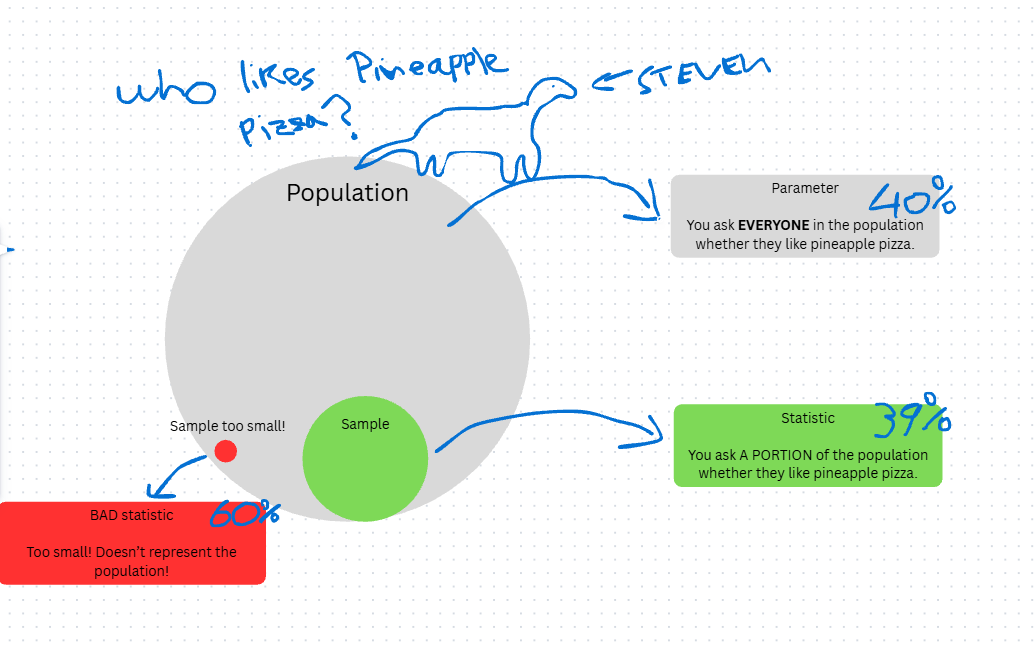


In [ ]:
# Since we have a metric ton of columns, let's make a for-loop that 
# gives the value counts of all the columns that mmay have isolated cases.
list_checkable_columns = [
    "school", "address", "famsize", "Pstatus",
    "Medu", "Fedu", "Mjob", "Fjob", "reason",
    "guardian", "studytime", "failures", "schoolsup",
    "famsup"
]

for column in list_checkable_columns:
    print(df[column].value_counts())
    print()


school
GP    349
MS     46
Name: count, dtype: int64

address
U    307
R     88
Name: count, dtype: int64

famsize
GT3    281
LE3    114
Name: count, dtype: int64

Pstatus
T    354
A     41
Name: count, dtype: int64

Medu
4    131
2    103
3     99
1     59
0      3
Name: count, dtype: int64

Fedu
2    115
3    100
4     96
1     82
0      2
Name: count, dtype: int64

Mjob
other       141
services    103
at_home      59
teacher      58
health       34
Name: count, dtype: int64

Fjob
other       217
services    111
teacher      29
at_home      20
health       18
Name: count, dtype: int64

reason
course        145
home          109
reputation    105
other          36
Name: count, dtype: int64

guardian
mother    273
father     90
other      32
Name: count, dtype: int64

studytime
2    198
1    105
3     65
4     27
Name: count, dtype: int64

failures
0    312
1     50
2     17
3     16
Name: count, dtype: int64

schoolsup
no     344
yes     51
Name: count, dtype: int64

famsup
yes    242

<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">


<i>
<h3>Observations</h3>

`Medu` (mother's education) and `Fedu`(father's education) have some isolated cases where the parents don't have any education at all. There's only up to 3 rows worth of cases for these situations.

Let's get rid of these cases.
</div>
</i>

---

### Transformation & Feature Engineering

|Step|Description|
|---|---|
|1|Data Cleaning |
|2|<bold style="background:yellow;color:black;">  Transformation & Feature Engineering</bold>|
|3| ML Training & Metrics|

---

### ML Training & Metrics

|Step|Description|
|---|---|
|1|Data Cleaning |
|2|Transformation & Feature Engineering|
|3|<bold style="background:yellow;color:black;">   ML Training & Metrics </bold>|

---

### Personal Analysis